<a href="https://colab.research.google.com/github/Karima-mtq/Basemap/blob/main/projection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 92.1 MB/s eta 0:00:00


In [1]:
!pip install netCDF4
!pip install eofs
!pip install Basemap

In [2]:
%matplotlib inline
import xarray as xr
import os
from scipy import signal
from netCDF4 import Dataset
from mpl_toolkits.basemap import Basemap
from eofs.standard import Eof
from netCDF4 import num2date
import numpy as np
import numpy.polynomial.polynomial as poly
import netCDF4 as netcdf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
import glob

In [36]:
!mkdir -p /content/grid_files

# Download the grid file
!wget -O /content/grid_files/areacello_fx_NorESM1-M_piControl_r0i0p0.nc \
"https://ns9039k.web.sigma2.no/datalake/mariko/grid/areacello_fx_NorESM1-M_piControl_r0i0p0.nc"

# Check that it downloaded
!ls -lh /content/grid_files

--2025-11-13 12:25:17--  https://ns9039k.web.sigma2.no/datalake/mariko/grid/areacello_fx_NorESM1-M_piControl_r0i0p0.nc
Resolving ns9039k.web.sigma2.no (ns9039k.web.sigma2.no)... 158.36.102.245
Connecting to ns9039k.web.sigma2.no (ns9039k.web.sigma2.no)|158.36.102.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5417124 (5.2M) [application/x-netcdf]
Saving to: ‘/content/grid_files/areacello_fx_NorESM1-M_piControl_r0i0p0.nc’

/content/grid_files 100%[===================>]   5.17M  5.20MB/s    in 1.0s    

2025-11-13 12:25:18 (5.20 MB/s) - ‘/content/grid_files/areacello_fx_NorESM1-M_piControl_r0i0p0.nc’ saved [5417124/5417124]

total 11M
-rw-r--r-- 1 root root 5.2M Oct 24 11:48 areacello_fx_NorESM1-M_piControl_r0i0p0.nc
-rw-r--r-- 1 root root 5.2M Oct 24 11:48 grid_tnx1v4_20170622.nc


In [ ]:
!mv "/content/grid_files/grid_tnx1v4_20170622.nc" "/content/drive/MyDrive/ODA_OCN/grid"

In [ ]:
grid = xr.open_dataset("/content/drive/MyDrive/ODA_OCN/grid/grid_tnx1v4_20170622.nc")
print(grid)

<xarray.Dataset> Size: 75MB
Dimensions:  (y: 385, x: 360, nv: 4, pcomp: 86708, qcomp: 88239, ucomp: 88642,
              vcomp: 87942)
Coordinates:
  * pcomp    (pcomp) int32 347kB 3667 3668 3670 3671 ... 138559 138560 138561
  * qcomp    (qcomp) int32 353kB 3668 3671 3672 3673 ... 138560 138561 138562
  * ucomp    (ucomp) int32 355kB 3667 3668 3669 3670 ... 138560 138561 138562
  * vcomp    (vcomp) int32 352kB 3667 3668 3670 3671 ... 138560 138561 138562
Dimensions without coordinates: y, x, nv
Data variables: (12/53)
    insw     (y, x) int32 554kB ...
    jnsw     (y, x) int32 554kB ...
    ins      (y, x) int32 554kB ...
    jns      (y, x) int32 554kB ...
    inse     (y, x) int32 554kB ...
    jnse     (y, x) int32 554kB ...
    ...       ...
    vdepth   (y, x) float64 1MB ...
    pmask    (y, x) int32 554kB ...
    umask    (y, x) int32 554kB ...
    vmask    (y, x) int32 554kB ...
    qmask    (y, x) int32 554kB ...
    cplmask  (y, x) int32 554kB ...
Attributes:
    nreg:    

In [163]:
print(grid)

<xarray.Dataset> Size: 5MB
Dimensions:       (j: 384, i: 320, vertices: 4)
Coordinates:
  * j             (j) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
  * i             (i) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
    lat           (j, i) float32 492kB -79.22 -79.22 -79.22 ... 72.2 72.19 72.19
    lon           (j, i) float32 492kB 320.6 321.7 322.8 ... 318.9 319.4 319.8
Dimensions without coordinates: vertices
Data variables:
    lat_vertices  (j, i, vertices) float32 2MB ...
    lon_vertices  (j, i, vertices) float32 2MB ...
    areacello     (j, i) float32 492kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/26)
    institution:            Norwegian Climate Centre
    institute_id:           NCC
    experiment_id:          piControl
    source:                 NorESM1-M 2011  atmosphere: CAM-Oslo (CAM4-Oslo-n...
    model_id:               NorESM1-M
    forcing:                N/A
    ...                     ...
    table_id:               

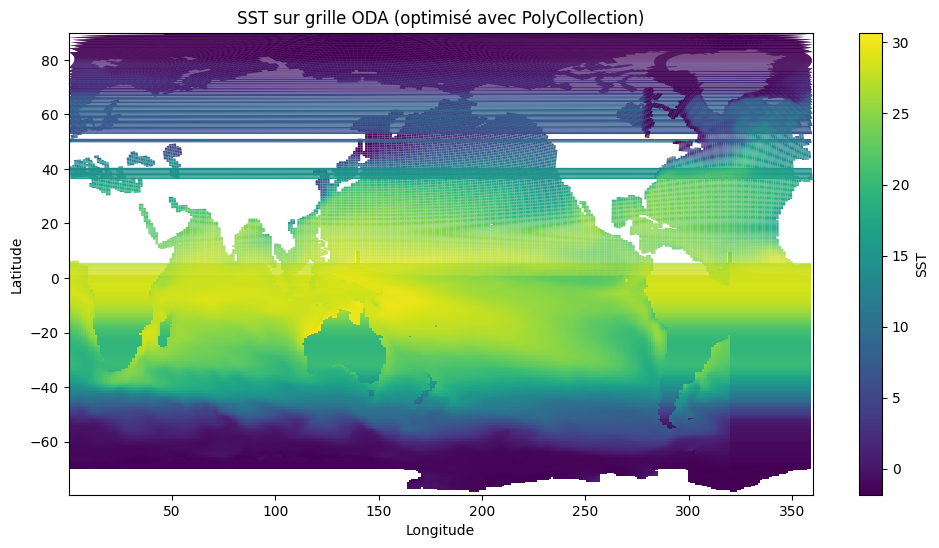

In [167]:
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import numpy as np

# Charger les vertices
lonv = grid['lon_vertices'].values  # (j, i, 4)
latv = grid['lat_vertices'].values
sst = ds_oda['sst'][0,:,:].values   # (j, i)

# Créer les polygones
polygons = [np.column_stack([lonv[j,i,:], latv[j,i,:]]) for j in range(sst.shape[0]) for i in range(sst.shape[1])]
colors = sst.flatten()

# Créer PolyCollection
collection = PolyCollection(polygons, array=colors, cmap='viridis', edgecolor='none')

fig, ax = plt.subplots(figsize=(12,6))
ax.add_collection(collection)

ax.set_xlim(lonv.min(), lonv.max())
ax.set_ylim(latv.min(), latv.max())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("SST sur grille ODA (optimisé avec PolyCollection)")
fig.colorbar(collection, ax=ax, label='SST')
plt.show()



In [9]:
#!apt-get install -y wget

 #Download all .nc files from the folder
!wget -r -np -nH --cut-dirs=5 -A "*ODA_ens.micom.hm.2006-12*.nc" \
    -P /content/drive/MyDrive/ODA_OCN \
    https://ns9039k.web.sigma2.no/datapeak/lgarcia/initializations/ODA/reana/ocn/

--2025-11-13 11:45:31--  https://ns9039k.web.sigma2.no/datapeak/lgarcia/initializations/ODA/reana/ocn/
Resolving ns9039k.web.sigma2.no (ns9039k.web.sigma2.no)... 158.36.102.245
Connecting to ns9039k.web.sigma2.no (ns9039k.web.sigma2.no)|158.36.102.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘/content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp’

ocn/index.html.tmp      [  <=>               ]  86.14K   354KB/s    in 0.2s    

2025-11-13 11:45:32 (354 KB/s) - ‘/content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp’ saved [88211]

Loading robots.txt; please ignore errors.
--2025-11-13 11:45:32--  https://ns9039k.web.sigma2.no/robots.txt
Reusing existing connection to ns9039k.web.sigma2.no:443.
HTTP request sent, awaiting response... 404 Not Found
2025-11-13 11:45:32 ERROR 404: Not Found.

Removing /content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp since it should be rejected.

--2025-11-13 11:45:32--  https://ns9039k.web.sigma2.n

In [10]:
all_files = sorted(glob.glob("/content/drive/MyDrive/ODA_OCN/ocn/ODA_ens.micom.hm.*.nc"))
files = [f for f in all_files if int(f.split('.')[-2].replace('-', '')) <= 201012]
# Use netCDF4 engine explicitly
ds_all = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4")
sst = ds_all['sst']
print(sst.shape)

(84, 384, 320)


/tmp/ipython-input-1867378452.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_all = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4")


In [11]:
# Extract the time values (cftime objects)
time_vals = ds_all['time'].values

# Get min and max years
year1 = min(t.year for t in time_vals)
year2 = max(t.year for t in time_vals)

print("Year range:", year1, "-", year2)

Year range: 2000 - 2006


In [12]:
sst_data = sst.values
nt,nlat,nlon = sst.shape
startY = year1
endY   = year2
ndy    = year2-year1+1
ny = nt/ndy
print(startY, endY, ndy, ny)

2000 2006 7 12.0


In [13]:
import numpy as np
import numpy.polynomial.polynomial as poly

# Dimensions
nt, nlat, nlon = sst_data.shape

sst_detrend = np.empty(sst_data.shape)
sst_coeffs  = np.empty((2, nlat, nlon))
sst_detrend[:,:,:] = np.nan

x = np.linspace(1, nt, nt)

for i in range(nlat):
    for j in range(nlon):
        y = sst_data[:, i, j]   # <-- use raw numpy array
        if np.all(np.isnan(y)):
            continue
        b = ~np.isnan(y)
        coefs = poly.polyfit(x[b], y[b], 1)
        sst_coeffs[0, i, j] = coefs[0]
        sst_coeffs[1, i, j] = coefs[1]
        ffit = poly.polyval(x[b], coefs)
        sst_detrend[b, i, j] = y[b] - ffit

In [14]:
sst_all = sst_detrend.reshape((ndy,int(ny),nlat,nlon), order='F').transpose((1,0,2,3)) # year, 36, lat, lon
sst_season = np.mean(sst_all, axis=0)
sst_diff = sst_all - sst_season
#mask_4d = np.broadcast_to((pmask_trimmed==0), sst_all.shape)
#sst_diff = np.ma.masked_array(sst_diff, mask=mask_4d) # have to do this, or fill in zeros in sst_diff.
sst_final = sst_diff.transpose((1,0,2,3)).reshape((ndy*int(ny),nlat,nlon), order='F')

In [15]:
lat = np.linspace(-90, 90, nlat)  # if first row is South
lon = np.linspace(-180, 180, nlon)

In [16]:
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(sst_final, weights=wgts)

print(coslat.shape)
print(wgts.shape)

(384,)
(384, 1)


In [17]:
eof1 = solver.eofs(neofs=10)
pc1  = solver.pcs(npcs=10, pcscaling=0)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

In [114]:
import xarray as xr

# Ouvrir le fichier NetCDF
path = "/content/drive/MyDrive/ODA_OCN/ocn/ODA_ens.micom.hm.2000-01.nc"
ds_oda = xr.open_dataset(path)

# Afficher un résumé du contenu
print(ds.attrs)
print(ds)

{'history': 'Tue Sep  5 16:01:16 2023: ncks -O -v sst,templvl,salnlvl,depth_bnds /cluster/work/users/lgarcia/data/nud_00/nud_00_ens.micom.hm.2000-01.nc /cluster/work/users/lgarcia/data/nud_00/nud_00_ens.micom.hm.2000-01.nc\nSun May  7 16:19:45 2023: ncea -v sst,fice,sealv,templvl,salnlvl,depth_bnds /nird/projects/NS9039K/shared/norcpm/cases/NorCPM/NorCPM_V1c/ana_19800115_me/ana_19800115_me_mem01/ocn/hist/ana_19800115_me_mem01.micom.hm.2000-01.nc /nird/projects/NS9039K/shared/norcpm/cases/NorCPM/NorCPM_V1c/ana_19800115_me/ana_19800115_me_mem02/ocn/hist/ana_19800115_me_mem02.micom.hm.2000-01.nc /nird/projects/NS9039K/shared/norcpm/cases/NorCPM/NorCPM_V1c/ana_19800115_me/ana_19800115_me_mem03/ocn/hist/ana_19800115_me_mem03.micom.hm.2000-01.nc /nird/projects/NS9039K/shared/norcpm/cases/NorCPM/NorCPM_V1c/ana_19800115_me/ana_19800115_me_mem04/ocn/hist/ana_19800115_me_mem04.micom.hm.2000-01.nc /nird/projects/NS9039K/shared/norcpm/cases/NorCPM/NorCPM_V1c/ana_19800115_me/ana_19800115_me_mem05/o

In [71]:
import xarray as xr

# Supposons que ton dataset ODA s'appelle ds_oda
# Et que tes coordonnées 2D se trouvent dans ds_grid['lat'], ds_grid['lon']
lat2d = grid['lat'].values
lon2d = grid['lon'].values

# Vérifier les dimensions
print(ds_oda.sst.shape)  # par exemple (time, y, x)
print(lat2d.shape, lon2d.shape)  # doivent correspondre à (y, x)

# Assigner les coordonnées lat/lon en 2D
ds_oda = ds_oda.assign_coords(
    lat=(('y', 'x'), lat2d),
    lon=(('y', 'x'), lon2d)
)

# Maintenant ds_oda['sst'].isel(time=0) aura lat/lon correspondantes
print(ds_oda)



(1, 384, 320)
(384, 320) (384, 320)
<xarray.Dataset> Size: 140MB
Dimensions:     (depth: 70, bounds: 2, time: 1, y: 384, x: 320)
Coordinates:
  * depth       (depth) float64 560B 0.0 5.0 10.0 ... 6.25e+03 6.5e+03 6.75e+03
  * time        (time) object 8B 2000-01-17 00:00:00
    lat         (y, x) float32 492kB -79.22 -79.22 -79.22 ... 72.2 72.19 72.19
    lon         (y, x) float32 492kB 320.6 321.7 322.8 ... 318.9 319.4 319.8
Dimensions without coordinates: bounds, y, x
Data variables:
    depth_bnds  (depth, bounds) float64 1kB ...
    salnlvl     (time, depth, y, x) float64 69MB ...
    sst         (time, y, x) float64 983kB ...
    templvl     (time, depth, y, x) float64 69MB ...
Attributes:
    history:  Tue Sep  5 16:01:16 2023: ncks -O -v sst,templvl,salnlvl,depth_...
    NCO:      netCDF Operators version 5.0.3 (Homepage = http://nco.sf.net, C...


In [72]:
# coins
print("Coin supérieur gauche :", ds_oda.lat[0,0].values, ds_oda.lon[0,0].values)
print("Coin supérieur droit :", ds_oda.lat[0,-1].values, ds_oda.lon[0,-1].values)
print("Coin inférieur gauche :", ds_oda.lat[-1,0].values, ds_oda.lon[-1,0].values)
print("Coin inférieur droit :", ds_oda.lat[-1,-1].values, ds_oda.lon[-1,-1].values)

# centre
print("Centre :", ds_oda.lat[ds_oda.dims['y']//2, ds_oda.dims['x']//2].values,
                  ds_oda.lon[ds_oda.dims['y']//2, ds_oda.dims['x']//2].values)


Coin supérieur gauche : -79.22052 320.5625
Coin supérieur droit : -79.22052 319.4375
Coin inférieur gauche : 72.185974 320.21652
Coin inférieur droit : 72.185974 319.7835
Centre : 1.4735379 140.5625


/tmp/ipython-input-777221391.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Centre :", ds_oda.lat[ds_oda.dims['y']//2, ds_oda.dims['x']//2].values,
/tmp/ipython-input-777221391.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds_oda.lon[ds_oda.dims['y']//2, ds_oda.dims['x']//2].values)


In [79]:
print(ds_oda.lat.shape)
print(ds_oda.lon.shape)
print(ds_oda.x.shape)
print(ds_oda.y.shape)

(384, 320)
(384, 320)
(320,)
(384,)


In [148]:
import numpy as np
import xarray as xr
# Dimensions du dataset
nx = ds_data.dims['x']  # 320
ny = ds_data.dims['y']  # 384

# Indices
x_indices = np.arange(nx)
y_indices = np.arange(ny)

# Définir correctement les coins
lat_min, lat_max = -55.3147, 74.3899
lon_min, lon_max = -42.2335, -38.4855  # attention, ici lon_max > lon_min pour x croissant

# Corriger les inversions : latitude croissante vers le haut, longitude croissante vers la droite
lat_bottom = min(lat_min, lat_max)
lat_top    = max(lat_min, lat_max)
lon_left   = min(lon_min, lon_max)
lon_right  = max(lon_min, lon_max)

# Créer des grilles linéaires
latitudes = np.linspace(lat_bottom, lat_top, ny)      # axe vertical
longitudes = np.linspace(lon_left, lon_right, nx)    # axe horizontal

# Créer les grilles 2D
lon2d, lat2d = np.meshgrid(longitudes, latitudes)

# Assigner au dataset
ds_data = ds_data.assign_coords(lat=(('y','x'), lat2d),
                                lon=(('y','x'), lon2d))



/tmp/ipython-input-713581611.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nx = ds_data.dims['x']  # 320
/tmp/ipython-input-713581611.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ny = ds_data.dims['y']  # 384


In [150]:
print(ds_data['lon'], ds_data['lat'])

<xarray.DataArray 'lon' (y: 384, x: 320)> Size: 983kB
array([[-42.2335    , -42.22175078, -42.21000157, ..., -38.50899843,
        -38.49724922, -38.4855    ],
       [-42.2335    , -42.22175078, -42.21000157, ..., -38.50899843,
        -38.49724922, -38.4855    ],
       [-42.2335    , -42.22175078, -42.21000157, ..., -38.50899843,
        -38.49724922, -38.4855    ],
       ...,
       [-42.2335    , -42.22175078, -42.21000157, ..., -38.50899843,
        -38.49724922, -38.4855    ],
       [-42.2335    , -42.22175078, -42.21000157, ..., -38.50899843,
        -38.49724922, -38.4855    ],
       [-42.2335    , -42.22175078, -42.21000157, ..., -38.50899843,
        -38.49724922, -38.4855    ]])
Coordinates:
    lat      (y, x) float64 983kB -55.31 -55.31 -55.31 ... 74.39 74.39 74.39
    lon      (y, x) float64 983kB -42.23 -42.22 -42.21 ... -38.51 -38.5 -38.49
Dimensions without coordinates: y, x <xarray.DataArray 'lat' (y: 384, x: 320)> Size: 983kB
array([[-55.3147    , -55.3147    , -

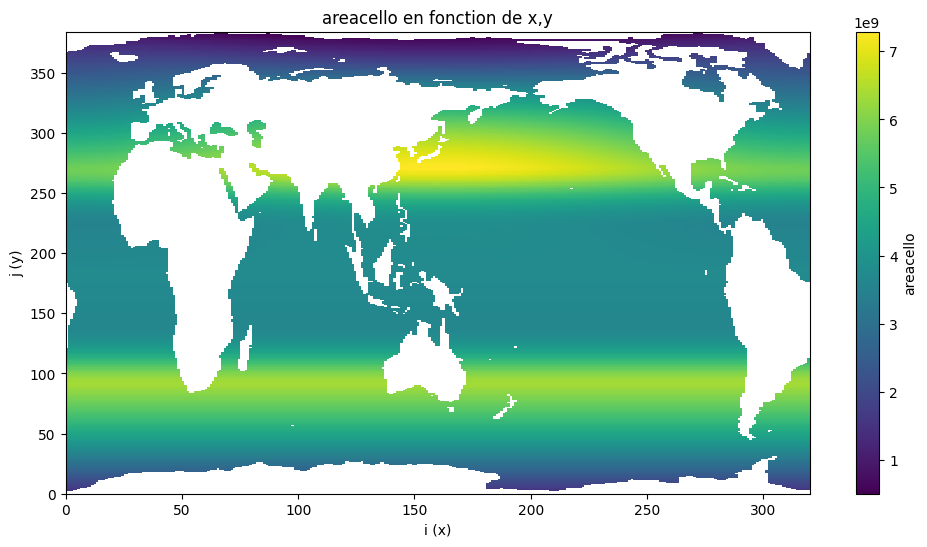

In [185]:
plt.figure(figsize=(12,6))
plt.pcolormesh(var, shading='auto', cmap='viridis')
plt.xlabel("i (x)")
plt.ylabel("j (y)")
plt.title("areacello en fonction de x,y")
plt.colorbar(label='areacello')
plt.show()



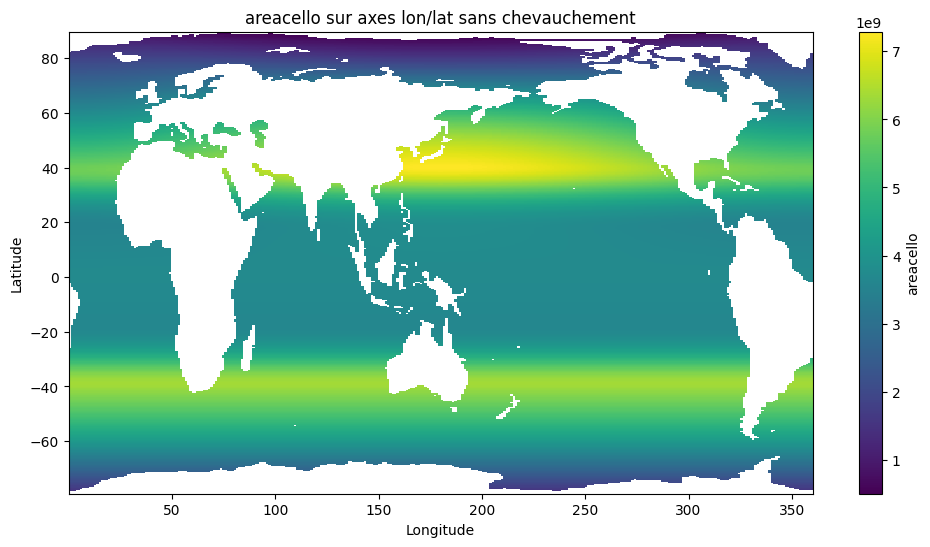

In [186]:
import matplotlib.pyplot as plt
import numpy as np

# Variable à tracer
var = grid['areacello'].values  # shape (j,i)

# Calculer les axes x (lon) et y (lat) aux "bords" des cellules
# On suppose que lon et lat sont 2D
lon = grid['lon'].values
lat = grid['lat'].values

# Axes horizontaux (longitude) : moyenne des colonnes
x = 0.5 * (lon[:, :-1] + lon[:, 1:])  # shape (j, i-1) → on peut prendre la moyenne simple si régulier
x = np.linspace(lon.min(), lon.max(), var.shape[1]+1)

# Axes verticaux (latitude) : moyenne des lignes
y = np.linspace(lat.min(), lat.max(), var.shape[0]+1)

# Plot
plt.figure(figsize=(12,6))
plt.pcolormesh(x, y, var, shading='auto', cmap='viridis')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("areacello sur axes lon/lat sans chevauchement")
plt.colorbar(label='areacello')
plt.show()


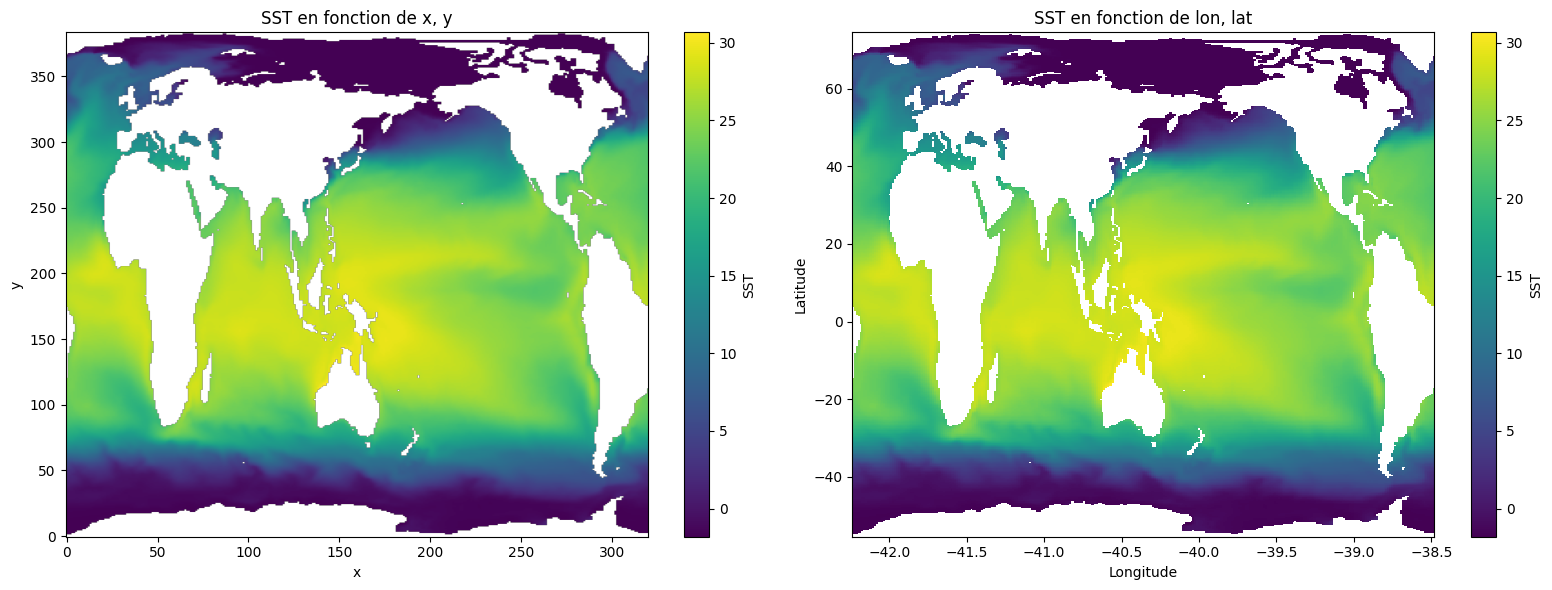

In [149]:
sst = ds_data['sst'][0,:,:]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# x/y
im0 = axes[0].imshow(sst, origin='lower', aspect='auto', cmap='viridis')
axes[0].set_title("SST en fonction de x, y")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], label='SST')

# lon/lat
im1 = axes[1].pcolormesh(ds_data['lon'], ds_data['lat'], sst, shading='auto', cmap='viridis')
axes[1].set_title("SST en fonction de lon, lat")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(im1, ax=axes[1], label='SST')

plt.tight_layout()
plt.show()

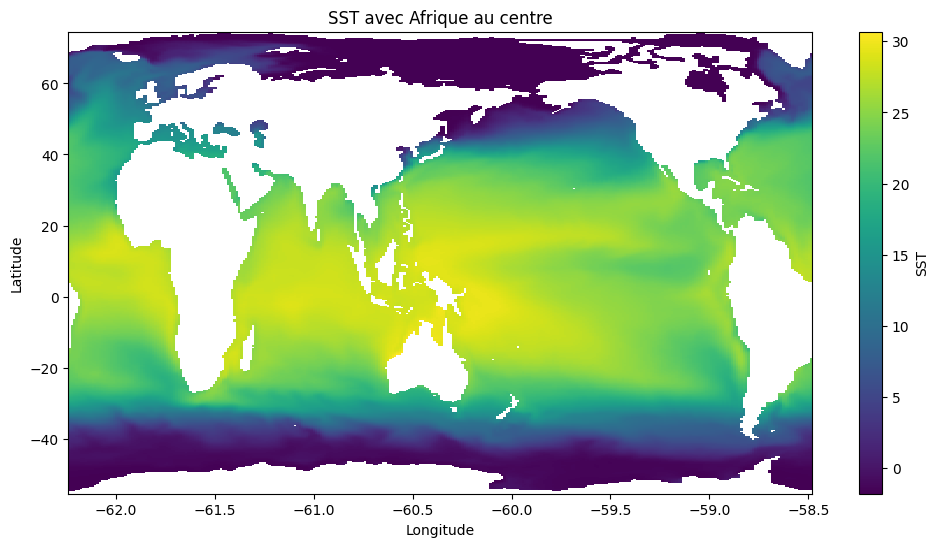

In [159]:
import numpy as np
import matplotlib.pyplot as plt

# Exemple : ds_data['lon'] et ds_data['lat'] couvrent tout le globe
lon = ds_data['lon'].values   # shape (ny, nx)
lat = ds_data['lat'].values
sst = ds_data['sst'][0,:,:].values

# 1️⃣ Définir le méridien central
lon_centre = 20  # Afrique au centre

# 2️⃣ Recentrer les longitudes (-180, 180)
lon_shifted = ((lon - lon_centre + 180) % 360) - 180

# 3️⃣ Trier les colonnes pour correspondre aux nouvelles longitudes
sort_idx = np.argsort(lon_shifted[0,:])  # prendre une ligne pour indices
lon_sorted = lon_shifted[:,sort_idx]
lat_sorted = lat[:,sort_idx]
sst_sorted = sst[:,sort_idx]

# 4️⃣ Plot
plt.figure(figsize=(12,6))
plt.pcolormesh(lon_sorted, lat_sorted, sst_sorted, shading='auto', cmap='viridis')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SST avec Afrique au centre")
plt.colorbar(label='SST')
plt.show()



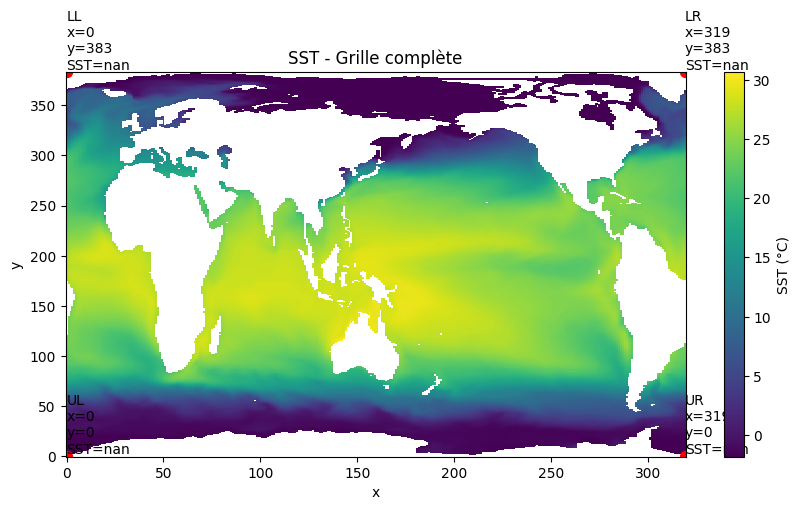

In [111]:
import matplotlib.pyplot as plt

sst = ds_oda['sst'].isel(time=0)  # premier timestep

# Coins de la grille entière
corners = {
    "UL": (0, 0),  # Upper Left
    "UR": (-1, 0), # Upper Right
    "LL": (0, -1), # Lower Left
    "LR": (-1, -1) # Lower Right
}

# Plot SST
plt.figure(figsize=(10,5))
pcm = plt.pcolormesh(ds_oda['x'], ds_oda['y'], sst, shading='auto', cmap='viridis')
plt.colorbar(label='SST (°C)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('SST - Grille complète')

# Annoter les coins
for name, (xi, yi) in corners.items():
    val = sst.isel(x=xi, y=yi).values
    plt.scatter(ds_oda['x'].isel(x=xi), ds_oda['y'].isel(y=yi), color='red', s=50)
    plt.text(ds_oda['x'].isel(x=xi), ds_oda['y'].isel(y=yi),
             f"{name}\nx={ds_oda['x'].isel(x=xi).values}\ny={ds_oda['y'].isel(y=yi).values}\nSST={val:.2f}",
             color='black', fontsize=10, ha='left', va='bottom')

plt.show()




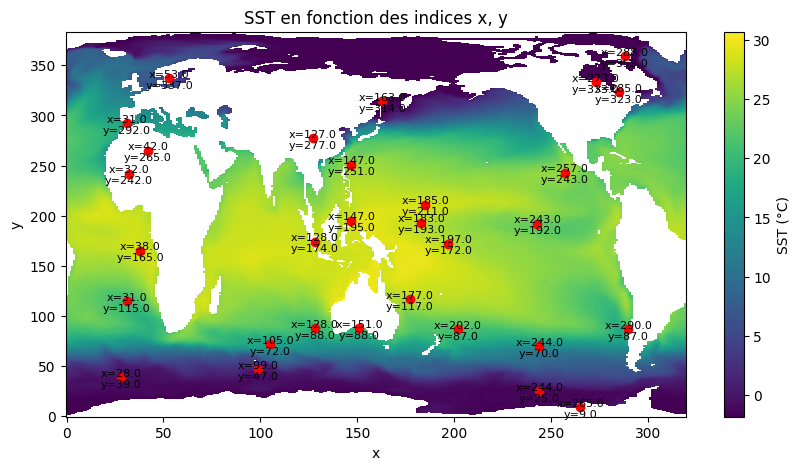

In [94]:
import numpy as np
import matplotlib.pyplot as plt

sst = ds_oda['sst'].isel(time=0)  # premier timestep

plt.figure(figsize=(10,5))
pcm = plt.pcolormesh(ds_oda['x'], ds_oda['y'], sst, shading='auto', cmap='viridis')
plt.colorbar(label='SST (°C)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('SST en fonction des indices x, y')

# Choisir quelques points au hasard pour annoter
np.random.seed(0)
ny, nx = sst.shape
num_points = 30
js = np.random.randint(0, ny, size=num_points)
is_ = np.random.randint(0, nx, size=num_points)

for j, i in zip(js, is_):
    x_val = ds_oda['x'][i].values
    y_val = ds_oda['y'][j].values
    sst_val = sst[j, i].values
    plt.scatter(x_val, y_val, color='red')
    # Annoter la valeur SST et coordonnées x/y
    plt.text(x_val, y_val+1, f'x={x_val:.1f}', color='black', fontsize=8, ha='center')
    #plt.text(x_val, y_val, f'SST={sst_val:.1f}', color='black', fontsize=8, ha='center', va='center')
    plt.text(x_val, y_val-10, f'y={y_val:.1f}', color='black', fontsize=8, ha='center')

plt.show()




In [50]:

# Ajouter lat/lon en tant que coordonnées correctement
ds_oda = ds_oda.assign_coords(
    lat=(('y','x'), lat2d.data),
    lon=(('y','x'), lon2d.data)
)

print(ds_oda['sst'].coords)


Coordinates:
  * time     (time) object 8B 2000-01-17 00:00:00
    lat      (y, x) float32 492kB -79.22 -79.22 -79.22 ... 72.2 72.19 72.19
    lon      (y, x) float32 492kB 320.6 321.7 322.8 323.9 ... 318.9 319.4 319.8


In [58]:
# Shift longitude si nécessaire
lon2d_mod = np.mod(lon2d, 360)  # toutes les longitudes entre 0 et 360
# ou pour -180/+180
lon2d_mod = (lon2d + 180) % 360 - 180


/tmp/ipython-input-456841792.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = m.pcolormesh(x, y, field_masked, cmap='RdBu_r', shading='auto')


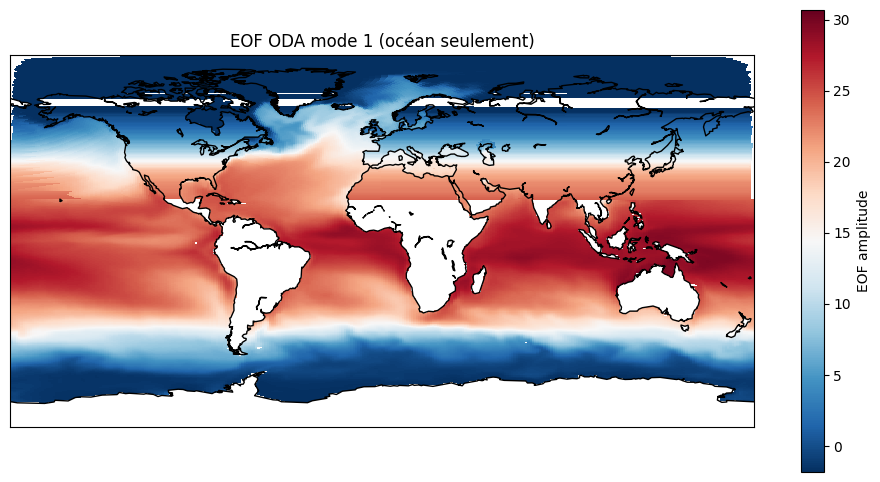

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

field = ds_oda['sst'][0, :, :].values
lat2d = ds_oda['lat'].values
lon2d = ds_oda['lon'].values
mask = grid['areacello'].values  # 1 pour océan, 0 pour continent

# Appliquer masque
field_masked = np.where(mask==0, np.nan, field)

# Recentrer longitudes et trier
lon2d = (lon2d + 180) % 360 - 180
sort_idx = np.argsort(lon2d[0, :])
lon2d = lon2d[:, sort_idx]
lat2d = lat2d[:, sort_idx]
field_masked = field_masked[:, sort_idx]

# Plot
plt.figure(figsize=(12,6))
m = Basemap(projection='cyl', llcrnrlon=-180, urcrnrlon=180,
            llcrnrlat=-90, urcrnrlat=90, resolution='c')
x, y = m(lon2d, lat2d)
cs = m.pcolormesh(x, y, field_masked, cmap='RdBu_r', shading='auto')
m.drawcoastlines()
plt.colorbar(cs, label='EOF amplitude')
plt.title('EOF ODA mode 1 (océan seulement)')
plt.show()



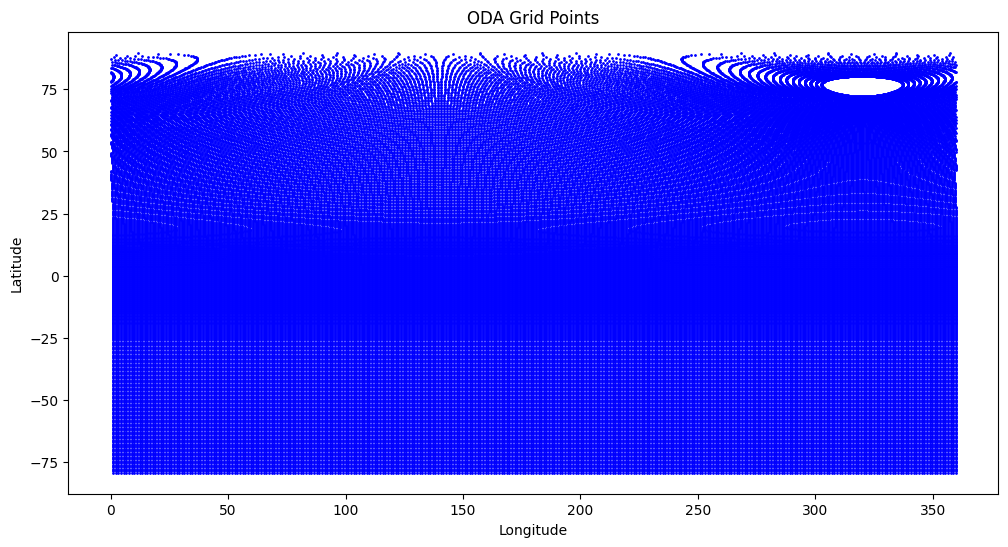

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.scatter(ds_oda['lon'], ds_oda['lat'], c='blue', s=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('ODA Grid Points')
plt.show()


In [49]:
import xarray as xr

# Charger le fichier ODA
ds_oda = xr.open_dataset("/content/drive/MyDrive/ODA_OCN/ocn/ODA_ens.micom.hm.2000-01.nc")

# Charger la grille NorESM
grid = xr.open_dataset("/content/grid_files/areacello_fx_NorESM1-M_piControl_r0i0p0.nc")
lat2d = grid['lat']
lon2d = grid['lon']

# Vérifier les dimensions
print(ds_oda['sst'].shape)  # ex: (time, y, x)
print(lat2d.shape, lon2d.shape)  # ex: (j, i) = (y, x)

# Ajouter lat/lon en tant que coordonnées
ds_oda = ds_oda.assign_coords(lat=(('y','x'), lat2d), lon=(('y','x'), lon2d))

# Maintenant tu peux accéder aux coordonnées
print(ds_oda['sst'].coords)


(1, 384, 320)
(384, 320) (384, 320)


TypeError: Variable 'lat': Using a DataArray object to construct a variable is ambiguous, please extract the data using the .data property.

In [44]:
print(ds["x"].shape)

(320,)


In [47]:
print(grid.dims)

FrozenMappingWarningOnValuesAccess({'j': 384, 'i': 320, 'vertices': 4})


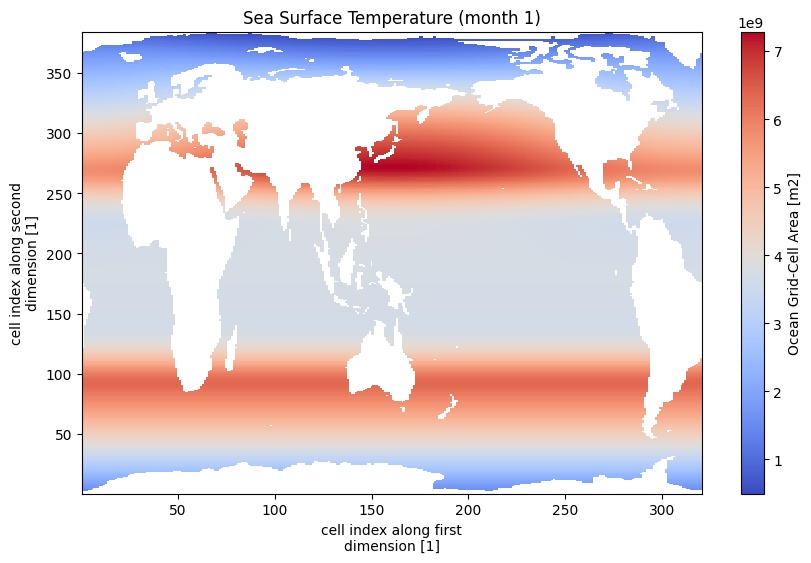

In [40]:
import matplotlib.pyplot as plt

# Exemple pour la variable 'sst'
var = grid['areacello']  # première date

plt.figure(figsize=(10,6))
var.plot(cmap="coolwarm")
plt.title("Sea Surface Temperature (month 1)")
plt.show()


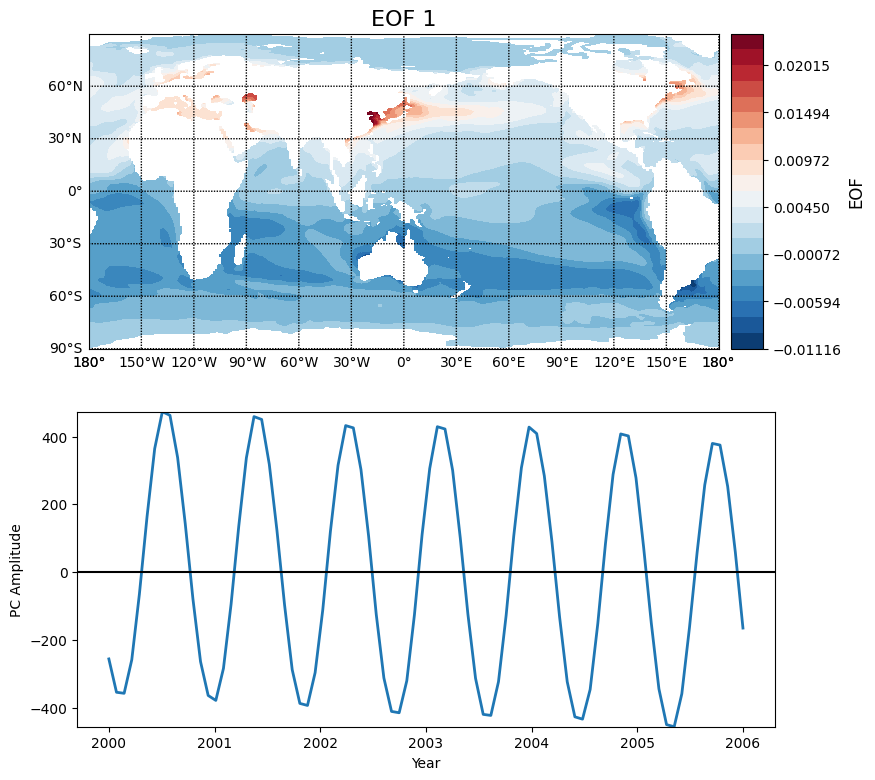

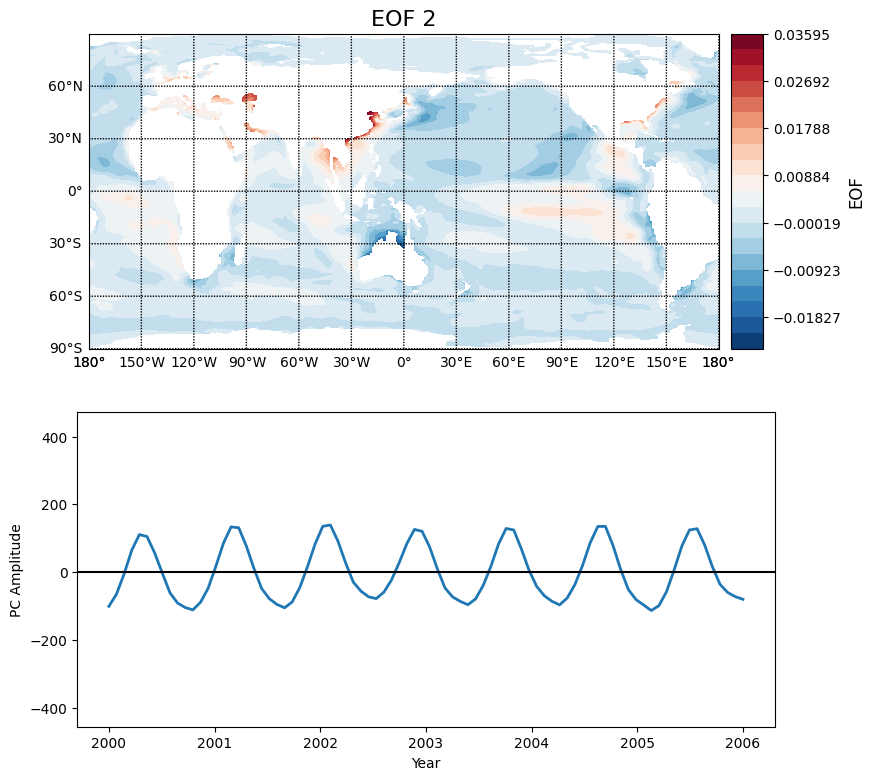

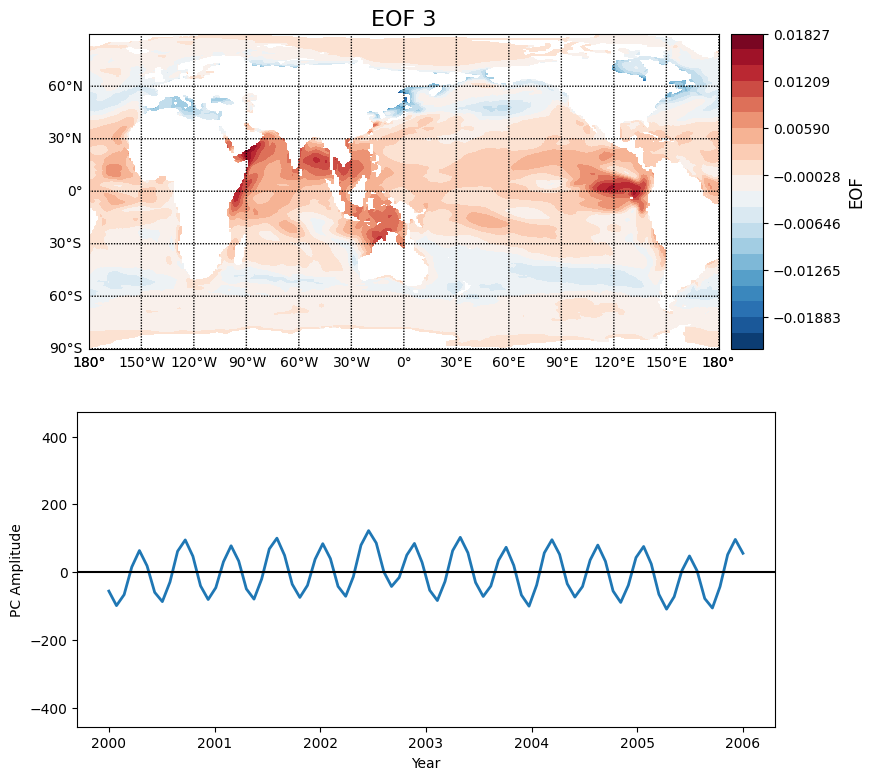

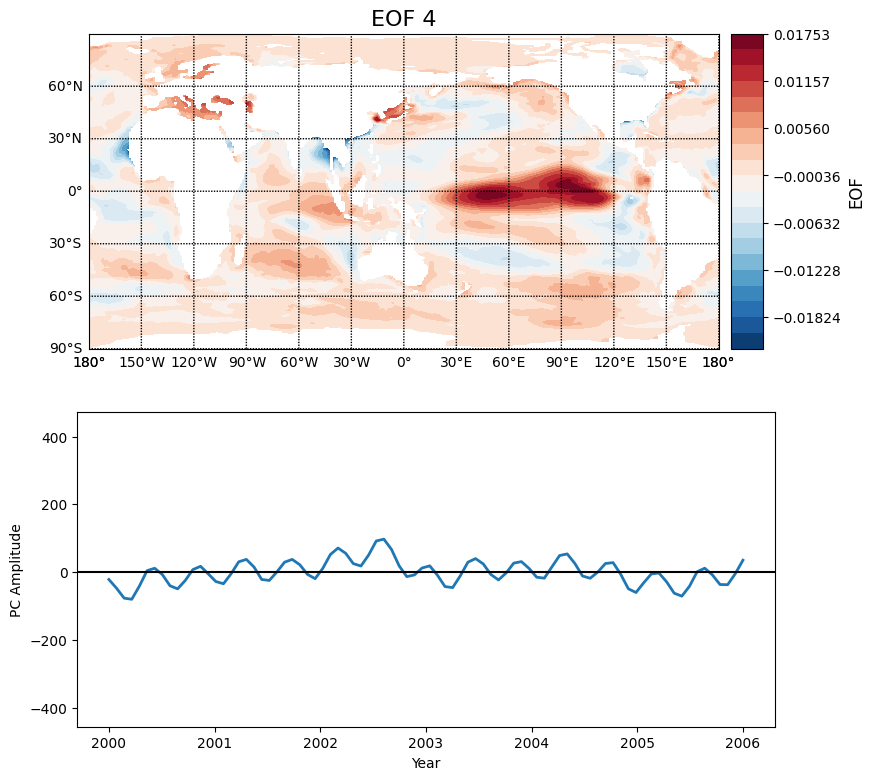

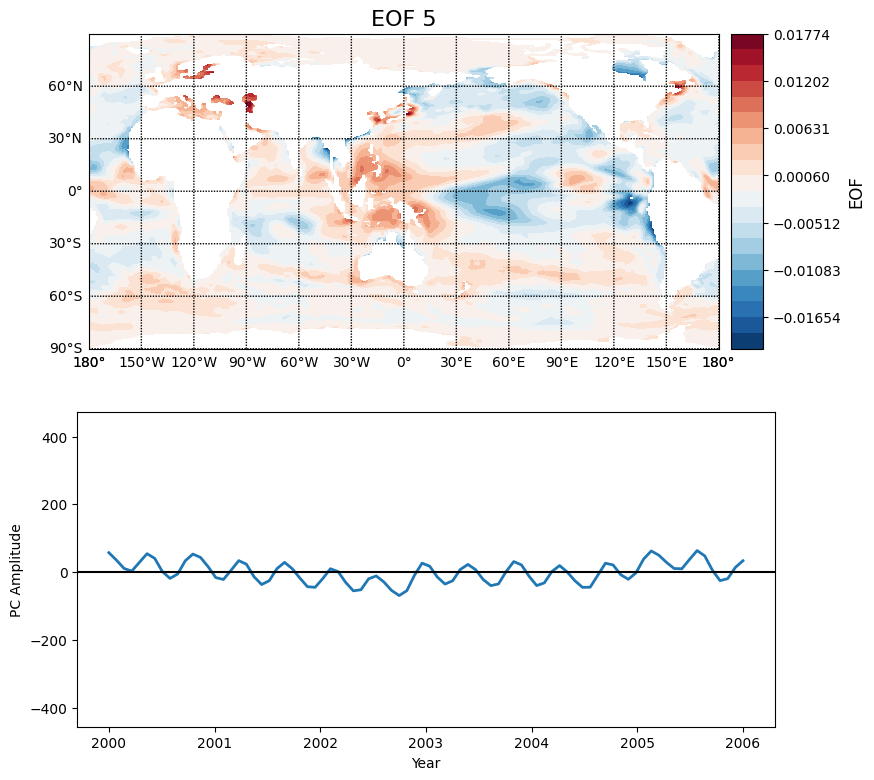

In [85]:
parallels = np.arange(-90,90,30.)
meridians = np.arange(-180,180,30)

for i in range(0,5):
    fig = plt.figure(figsize=(9,9))
    plt.subplot(211)

    m = Basemap(projection='cyl', llcrnrlon=min(lon), llcrnrlat=min(lat), urcrnrlon=max(lon), urcrnrlat=max(lat))
    x, y = m(*np.meshgrid(lon, lat))
    field = eof1[i, :, :].squeeze()

    # Remove NaNs before finding min/max
    valid = np.isfinite(field)
    vmin = field[valid].min()
    vmax = field[valid].max()

    clevs = np.linspace(vmin, vmax, 21)
    cs = m.contourf(x, y, field, clevs, cmap=plt.cm.RdBu_r)
    #m.drawcoastlines()
    m.drawparallels(parallels, labels=[1,0,0,0])
    m.drawmeridians(meridians, labels=[1,0,0,1])

    cb = m.colorbar(cs, 'right', size='5%', pad='2%')
    cb.set_label('EOF', fontsize=12)
    plt.title('EOF ' + str(i+1), fontsize=16)

    plt.subplot(212)
    #days = np.linspace(year1,year2,int(nt))
    days = np.linspace(year1, year2, int(nt))
    plt.plot(days, pc1[:,i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xlabel('Year')
    plt.ylabel('PC Amplitude')
    plt.ylim(np.min(pc1.squeeze()), np.max(pc1.squeeze()))

    #plt.savefig('EOF' + str(i+1)+'.png')
    #plt.savefig('EOF' + str(i+1)+'.pdf')

(5.036060355815479e-33, 0.8316544893501978)

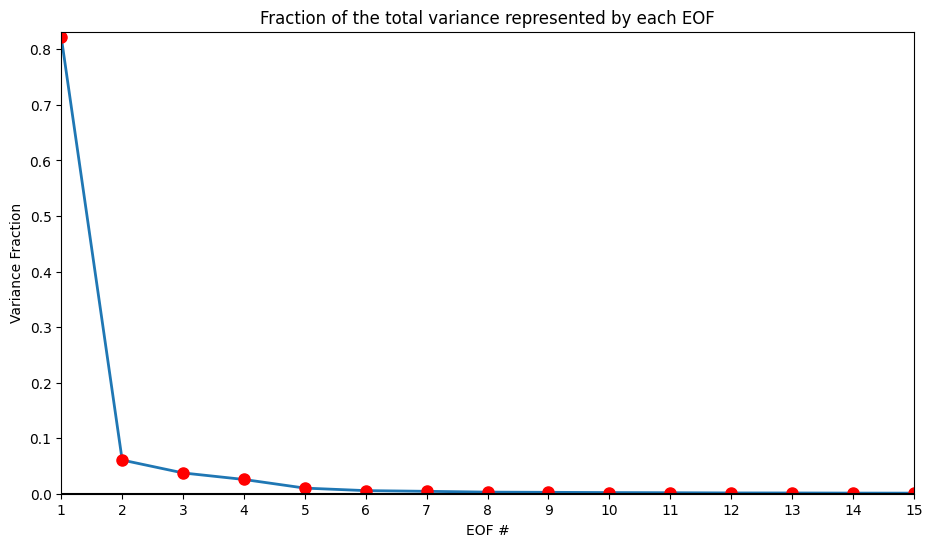

In [ ]:
plt.figure(figsize=(11,6))
eof_num = range(1, 16)
plt.plot(eof_num, varfrac[0:15], linewidth=2)
plt.plot(eof_num, varfrac[0:15], linestyle='None', marker="o", color='r', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 16))
plt.title('Fraction of the total variance represented by each EOF')
plt.xlabel('EOF #')
plt.ylabel('Variance Fraction')
plt.xlim(1, 15)
plt.ylim(np.min(varfrac), np.max(varfrac)+0.01)
#plt.savefig('ScreePlot-Explained-Variance.png')
#plt.savefig('ScreePlot-Explained-Variance.pdf')

In [ ]:
sum = 0
for i in range(0, 5):
    sum = sum + round(varfrac[i]*100)
    print("EOF", i, "explain", round(varfrac[i]*100), "%",", variance Cumulée :", sum, "%")

EOF 0 explain 82 % , variance Cumulée : 82 %
EOF 1 explain 6 % , variance Cumulée : 88 %
EOF 2 explain 4 % , variance Cumulée : 92 %
EOF 3 explain 3 % , variance Cumulée : 95 %
EOF 4 explain 1 % , variance Cumulée : 96 %


In [87]:
import xarray as xr
import numpy as np

# Recréer les lat/lon si besoin
lat = np.linspace(-89.5, 89.5, eof1.shape[1])
lon = np.linspace(0.5, 359.5, eof1.shape[2])

# Ajuster les longueurs pour correspondre au nombre de modes
nmodes = eof1.shape[0]

# Créer le Dataset cohérent
ds = xr.Dataset(
    {
        "EOFs": (("mode", "lat", "lon"), eof1),
        "PCs": (("time", "mode"), pc1),
        "variance_fraction": ("mode", varfrac[:nmodes]),
        "eigenvalues": ("mode", lambdas[:nmodes])
    },
    coords={
        "lat": lat,
        "lon": lon
    }
)

# Sauvegarder
ds.to_netcdf("/content/drive/MyDrive/EOF_results/EOFs_oda_summary.nc")

print("✅ Fichier NetCDF sauvegardé avec succès avec coordonnées lat/lon et dimensions cohérentes.")



✅ Fichier NetCDF sauvegardé avec succès avec coordonnées lat/lon et dimensions cohérentes.


In [88]:
ds_oda = xr.open_dataset("/content/drive/MyDrive/EOF_results/EOFs_oda_summary.nc")

# Afficher un résumé général du contenu
print(ds_oda)
ds_oda["PCs"].shape[0]

<xarray.Dataset> Size: 10MB
Dimensions:            (mode: 10, lat: 384, lon: 320, time: 84)
Coordinates:
  * lat                (lat) float64 3kB -89.5 -89.03 -88.57 ... 89.03 89.5
  * lon                (lon) float64 3kB 0.5 1.625 2.751 ... 357.2 358.4 359.5
Dimensions without coordinates: mode, time
Data variables:
    EOFs               (mode, lat, lon) float64 10MB ...
    PCs                (time, mode) float64 7kB ...
    variance_fraction  (mode) float64 80B ...
    eigenvalues        (mode) float64 80B ...


84

In [89]:
# Extraire les EOFs sous forme de DataArray
eof1 = ds_oda["EOFs"]
pc1 = ds_oda["PCs"]
# Afficher la forme et un aperçu
print(eof1.shape)
print(eof1)
nt = ds_oda["PCs"].shape[0]

(10, 384, 320)
<xarray.DataArray 'EOFs' (mode: 10, lat: 384, lon: 320)> Size: 10MB
[1228800 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 3kB -89.5 -89.03 -88.57 -88.1 ... 88.57 89.03 89.5
  * lon      (lon) float64 3kB 0.5 1.625 2.751 3.876 ... 356.1 357.2 358.4 359.5
Dimensions without coordinates: mode


In [94]:
lon = ds_oda["lon"]
lat = ds_oda["lat"]
year1 = 2000
year2 = 2006


In [91]:
days.shape
pc1.shape

(84, 10)

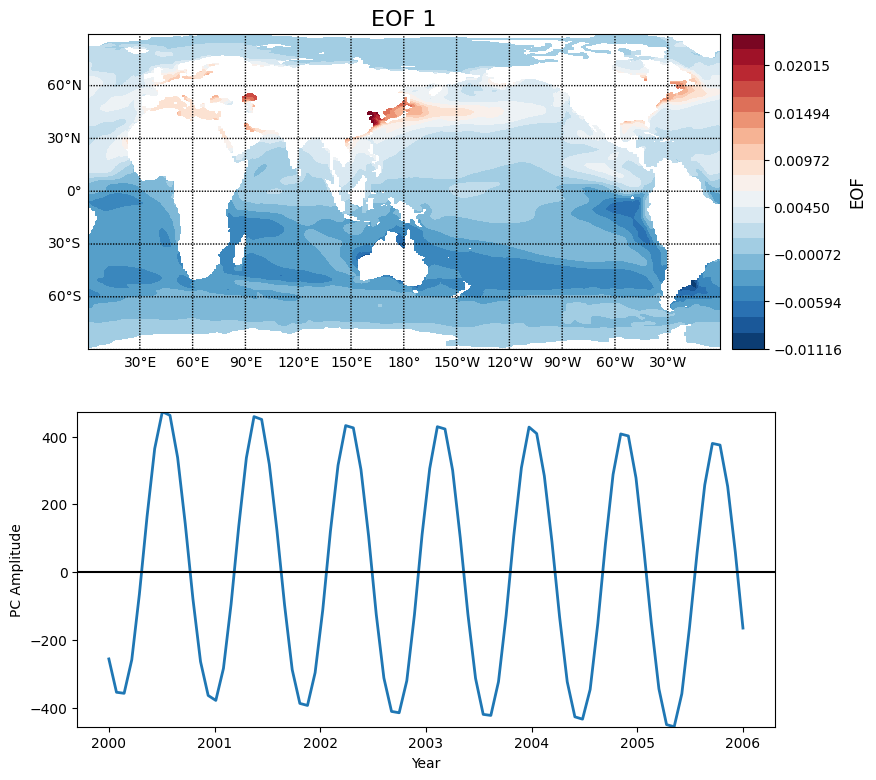

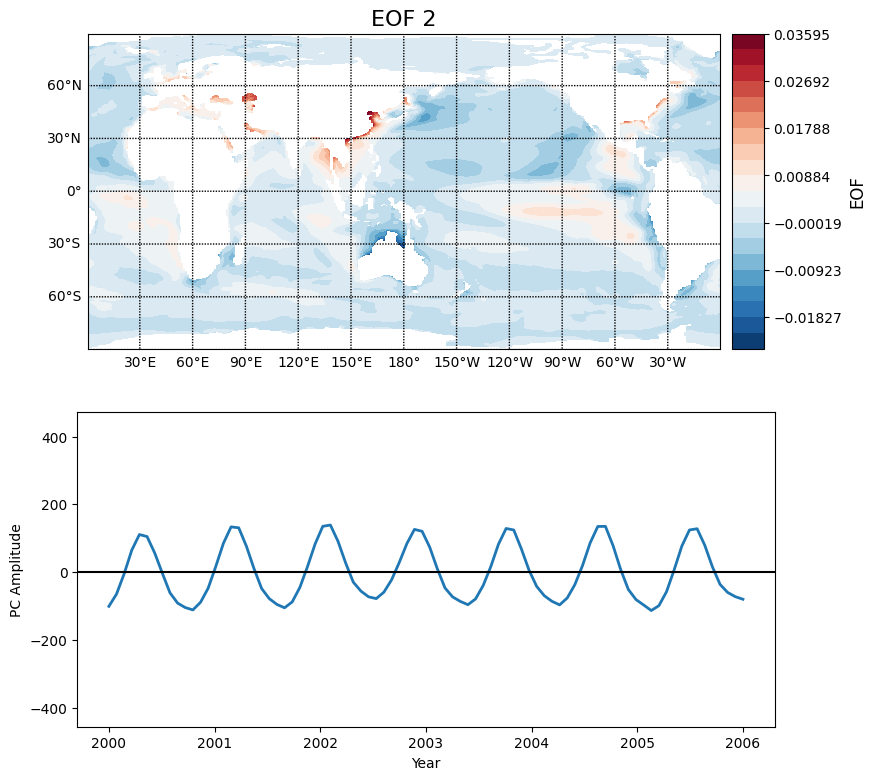

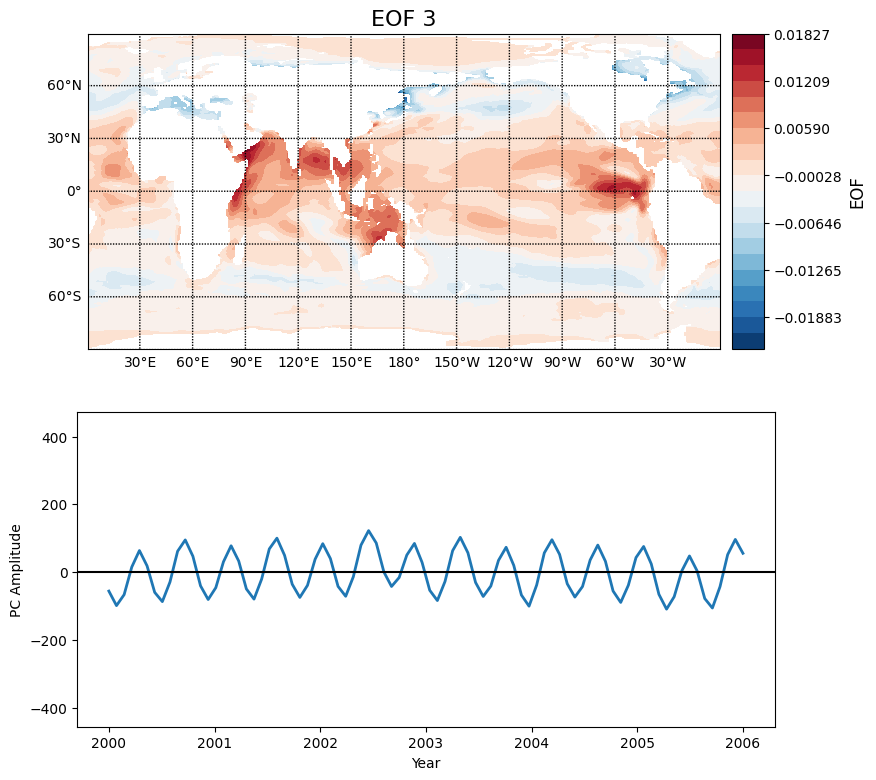

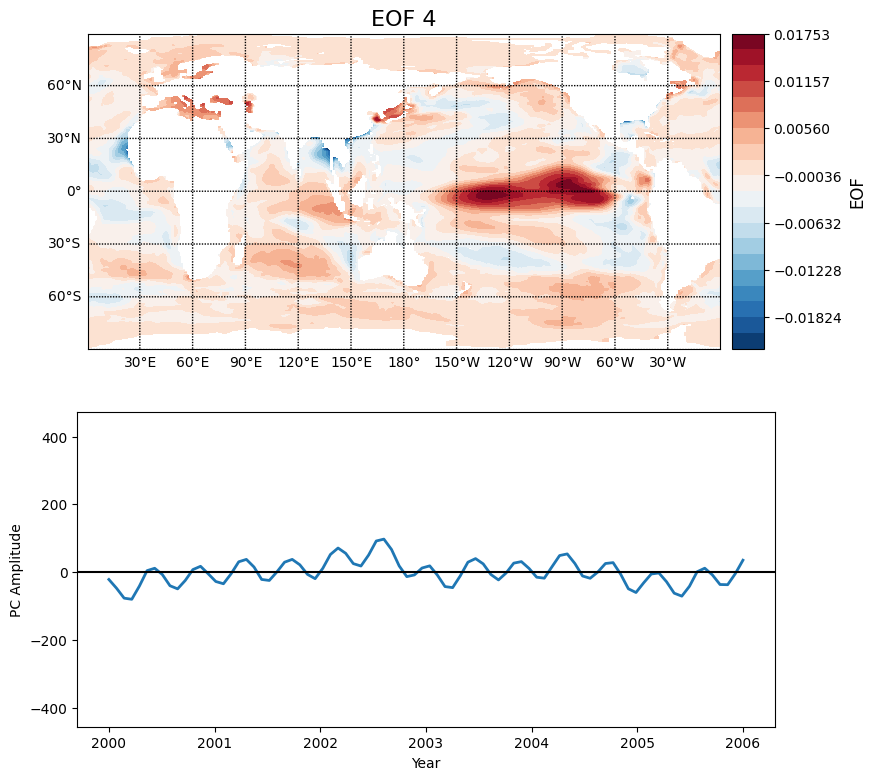

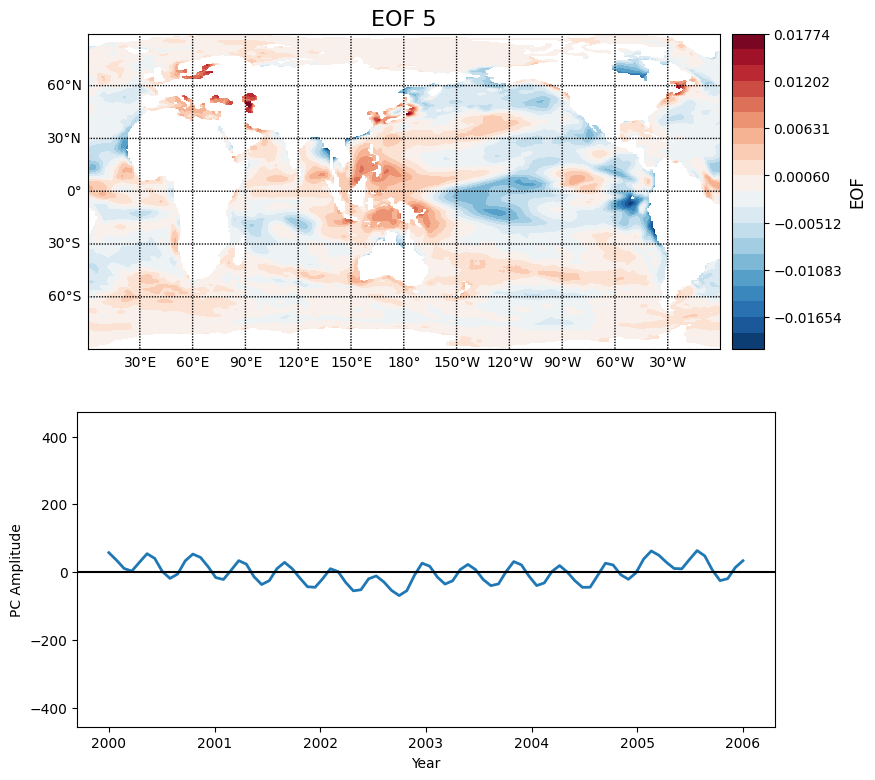

In [95]:
parallels = np.arange(-90,90,30.)
meridians = np.arange(-180,180,30)

for i in range(0,5):
    fig = plt.figure(figsize=(9,9))
    plt.subplot(211)

    m = Basemap(projection='cyl', llcrnrlon=min(lon), llcrnrlat=min(lat), urcrnrlon=max(lon), urcrnrlat=max(lat))
    x, y = m(*np.meshgrid(lon, lat))
    field = eof1[i, :, :].squeeze()

    # Remove NaNs before finding min/max
    # Remove NaNs before finding min/max
    field_np = field.values  # conversion en numpy

    # Créer un masque valide (sans NaN)
    valid = np.isfinite(field_np)

    # Calculer les min/max seulement sur les valeurs valides
    vmin = field_np[valid].min()
    vmax = field_np[valid].max()

    clevs = np.linspace(vmin, vmax, 21)
    cs = m.contourf(x, y, field, clevs, cmap=plt.cm.RdBu_r)
    #m.drawcoastlines()
    m.drawparallels(parallels, labels=[1,0,0,0])
    m.drawmeridians(meridians, labels=[1,0,0,1])

    cb = m.colorbar(cs, 'right', size='5%', pad='2%')
    cb.set_label('EOF', fontsize=12)
    plt.title('EOF ' + str(i+1), fontsize=16)

    plt.subplot(212)
    #days = np.linspace(year1,year2,int(nt))
    days = np.linspace(year1, year2, int(nt))
    plt.plot(days, pc1[:,i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xlabel('Year')
    plt.ylabel('PC Amplitude')
    plt.ylim(np.min(pc1.squeeze()), np.max(pc1.squeeze()))

    #plt.savefig('EOF' + str(i+1)+'.png')
    #plt.savefig('EOF' + str(i+1)+'.pdf')

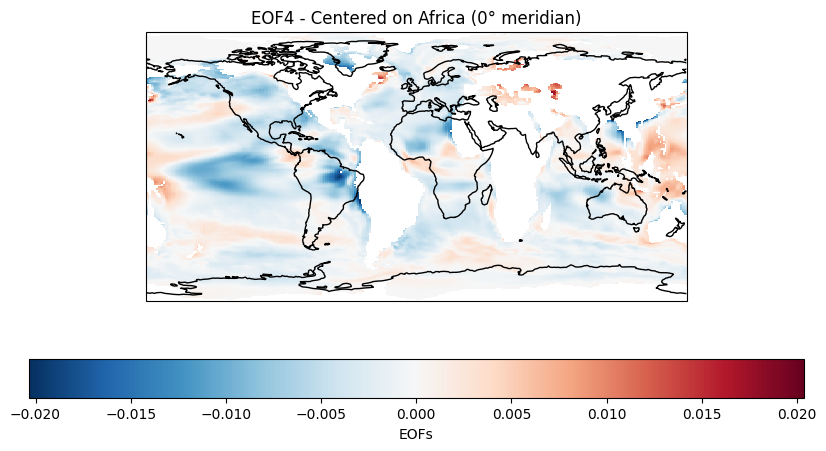

In [109]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


# Open your dataset
ds = xr.open_dataset("/content/drive/MyDrive/EOF_results/EOFs_oda_summary.nc")

# Example: select one EOF mode
field = ds["EOFs"].isel(mode=4)

# Convert lon from [0, 360] to [-180, 180]
lon = ds.lon
lon_new = ((lon + 180) % 360) - 180
field = field.assign_coords(lon=lon_new)

# Sort longitudes
field = field.sortby("lon")

# Plot it
plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))  # Africa at center
field.plot(
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    cbar_kwargs={"orientation": "horizontal"}
)
ax.coastlines()
plt.title("EOF4 - Centered on Africa (0° meridian)")
plt.show()




IndexError: 2-dimensional boolean indexing is not supported. 

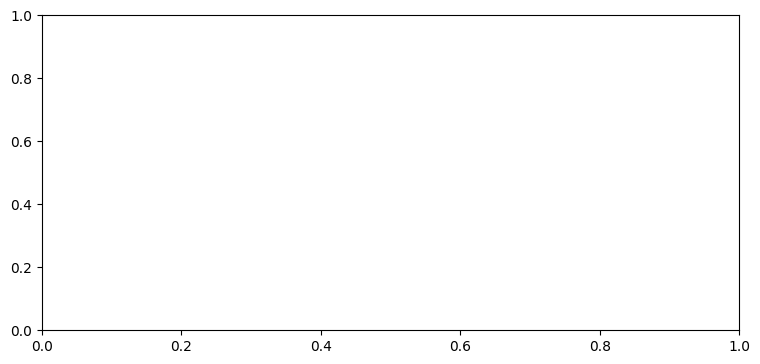

In [14]:
parallels = np.arange(-90,90,30.)
meridians = np.arange(-180,180,30)

for i in range(0,5):
    fig = plt.figure(figsize=(9,9))
    plt.subplot(211)

    m = Basemap(projection='cyl', llcrnrlon=min(lon), llcrnrlat=min(lat), urcrnrlon=max(lon), urcrnrlat=max(lat))
    x, y = m(*np.meshgrid(lon, lat))
    field = eof1[i, :, :].squeeze()

    # Remove NaNs before finding min/max
    valid = np.isfinite(field)
    vmin = field[valid].min()
    vmax = field[valid].max()

    clevs = np.linspace(vmin, vmax, 21)
    cs = m.contourf(x, y, field, clevs, cmap=plt.cm.RdBu_r)
    #m.drawcoastlines()
    m.drawparallels(parallels, labels=[1,0,0,0])
    m.drawmeridians(meridians, labels=[1,0,0,1])

    cb = m.colorbar(cs, 'right', size='5%', pad='2%')
    cb.set_label('EOF', fontsize=12)
    plt.title('EOF ' + str(i+1), fontsize=16)

    plt.subplot(212)
    #days = np.linspace(year1,year2,int(nt))
    days = np.linspace(year1, year2, int(nt))
    plt.plot(days, pc1[:,i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xlabel('Year')
    plt.ylabel('PC Amplitude')
    plt.ylim(np.min(pc1.squeeze()), np.max(pc1.squeeze()))

    #plt.savefig('EOF' + str(i+1)+'.png')
    #plt.savefig('EOF' + str(i+1)+'.pdf')